# 1 — Quick start: run a global ocean model, then differentiate it

`fesom-jax` is the [FESOM2](https://fesom.de) ocean circulation model rewritten in
[JAX](https://docs.jax.dev). It does everything an ocean model does — currents, temperature,
salinity, sea ice — but because it is written in JAX, **you can take the derivative of the
answer with respect to anything that went into it.** That is what makes it useful for machine
learning: you can train a neural network *through* the ocean physics.

This notebook runs on a **laptop CPU in about two minutes** and needs **no data downloads**.
It uses the small `pi` test mesh, which ships inside the package.

| | |
|---|---|
| **Mesh** | `pi` — a coarse global ocean, 3,140 points, 48 depth levels (ships with `fesom-jax`) |
| **Hardware** | any CPU. A GPU works too, and is faster |
| **Data needed** | none |
| **Runtime** | ~2 minutes |

When you want the *realistic* setup — the real global ocean at 1°, driven by actual observed
weather — go to [`02_core2_realistic.ipynb`](02_core2_realistic.ipynb).

---
## Setup

In [1]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import fesom_jax                     # importing the package turns on float64 (see below)

print("JAX     ", jax.__version__)
print("device  ", jax.devices()[0])
print("float64 ", jnp.zeros(1).dtype)   # must be float64 — the ocean needs it

JAX      0.10.1
device   cpu:0
float64  float64


> **Why float64?** Ocean models track tiny density differences between huge numbers. In JAX's
> default 32-bit mode the model is about twice as fast and completely wrong. `fesom_jax` therefore
> switches on 64-bit at import; you never have to think about it.

---
## The mesh

FESOM2 is an *unstructured-mesh* model: instead of a lat/lon grid of boxes, the ocean is covered by
triangles, which can be small where you need detail and large where you don't. Land is simply absent
— there are no wasted grid points.

The `pi` mesh is the coarsest one, meant for testing. It ships inside the package, so this just works.

In [2]:
from fesom_jax.mesh import load_mesh, DEFAULT_PI_MESH_DIR

mesh = load_mesh()                         # no argument => the packaged pi mesh
print("mesh dir :", DEFAULT_PI_MESH_DIR)
print(f"nodes    : {mesh.nod2D:,}  (points where temperature/salinity live)")
print(f"triangles: {mesh.elem2D:,}  (cells where velocity lives)")
print(f"levels   : {mesh.nl}  (depth levels, down to {-float(jnp.min(mesh.depth)):.0f} m)")

mesh dir : /home/a/a270088/port_jax/fesom_jax/data/mesh_pi
nodes    : 3,140  (points where temperature/salinity live)
triangles: 5,839  (cells where velocity lives)
levels   : 48  (depth levels, down to 6000 m)


### A plotting helper

Everything below is a value per mesh node, so one helper draws them all. The only subtlety: a few
triangles straddle the 0°/360° seam, and they would smear across the whole map, so we hide them.

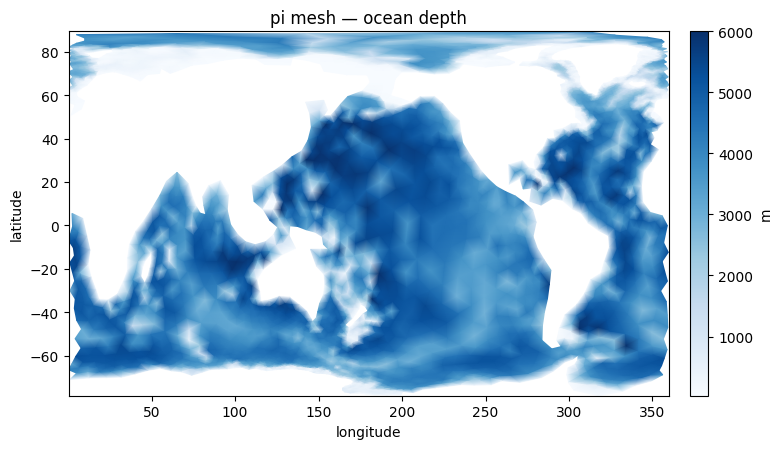

In [3]:
lon, lat = np.degrees(np.asarray(mesh.geo_coord_nod2D)).T
tris = np.asarray(mesh.elem_nodes)

# hide the triangles that wrap around the 0/360 seam
wrap = np.abs(lon[tris] - lon[tris][:, [0]]).max(axis=1) > 180
triang = mtri.Triangulation(lon, lat, tris, mask=wrap)

def plot_field(values, title, cmap="viridis", units="", **kw):
    fig, ax = plt.subplots(figsize=(11, 4.6))
    tpc = ax.tripcolor(triang, np.asarray(values), cmap=cmap, shading="gouraud", **kw)
    fig.colorbar(tpc, ax=ax, label=units, pad=0.02)
    # limits come from the mesh: pi is 0..360, but the CORE2 mesh is -180..180
    ax.set(title=title, xlabel="longitude", ylabel="latitude",
           xlim=(lon.min(), lon.max()), ylim=(lat.min(), lat.max()))
    ax.set_aspect(1.3)
    plt.tight_layout()
    plt.show()

plot_field(-np.asarray(mesh.depth), "pi mesh — ocean depth", cmap="Blues", units="m")

That is a real (if very blurry) world ocean: you can make out the Atlantic, the Pacific, and the
deep basins. 3,140 points is far too coarse for science — that is the point, it makes this notebook
fast.

---
## The initial state

We start the ocean at rest — no currents, flat surface — with uniform water (10 °C, 35 psu) plus a
**warm blob** dropped into the tropics. Watching that blob is the whole experiment.

surface T: 10.00 .. 14.99 °C
currents : 0.00 m/s   (at rest)


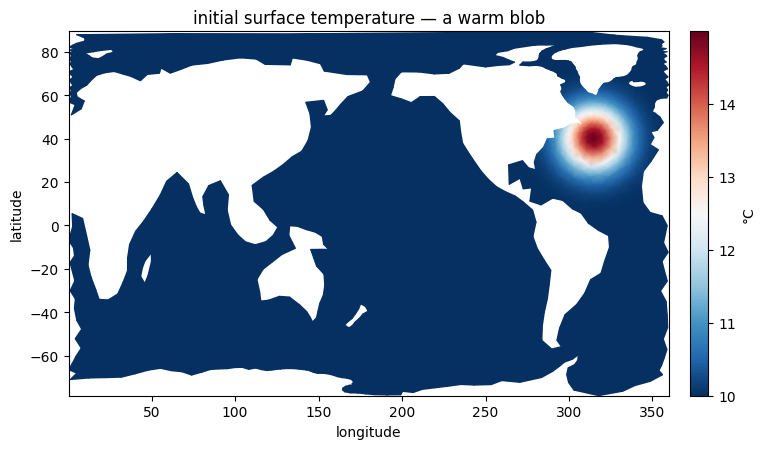

In [4]:
from fesom_jax import ic

state0 = ic.initial_state(mesh)          # 10 °C / 35 psu, at rest, + a warm blob

print(f"surface T: {float(state0.T[:, 0].min()):.2f} .. {float(state0.T[:, 0].max()):.2f} °C")
print(f"currents : {float(jnp.max(jnp.abs(state0.uv))):.2f} m/s   (at rest)")
plot_field(state0.T[:, 0], "initial surface temperature — a warm blob", cmap="RdBu_r", units="°C")

---
## Run the model

Now integrate forward. `integrate` takes the state, the mesh, a pre-built solver for the sea-surface
height, the wind stress (zero here — we want to see the blob alone), and a number of steps.

Each step is 100 seconds of ocean time, so 300 steps ≈ **8 hours** of ocean.

In [5]:
from fesom_jax.ssh import build_ssh_operator
from fesom_jax.integrate import integrate

DT, N_STEPS = 100.0, 300

op = build_ssh_operator(mesh, dt=DT)              # sea-surface-height solver (built once)
stress = jnp.zeros((mesh.elem2D, 2))             # no wind

t0 = time.time()
state = integrate(state0, mesh, op, stress, n_steps=N_STEPS, dt=DT)
state.T.block_until_ready()                       # JAX is async; wait for the real answer
print(f"{N_STEPS} steps ({N_STEPS * DT / 3600:.1f} ocean-hours) in {time.time() - t0:.1f} s")

300 steps (8.3 ocean-hours) in 29.1 s


> The first call is slow because JAX **compiles** the whole timestep to optimised machine code.
> That compiled code is then reused, so a second, longer run costs far less per step. This is why
> JAX can be fast despite being Python.

### What happened?

Warm water is lighter, so the blob makes the sea surface **bulge upward**. On a rotating planet the
water cannot simply flow downhill off the bulge — the Coriolis force deflects it — so instead it
ends up circling around it. This is **geostrophic balance**, and it is the single most important
fact about large-scale ocean currents.

The model was never told any of this. It falls out of the equations.

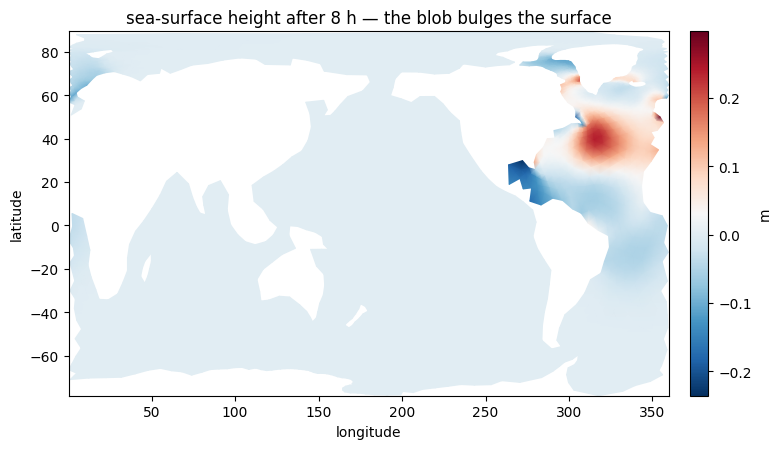

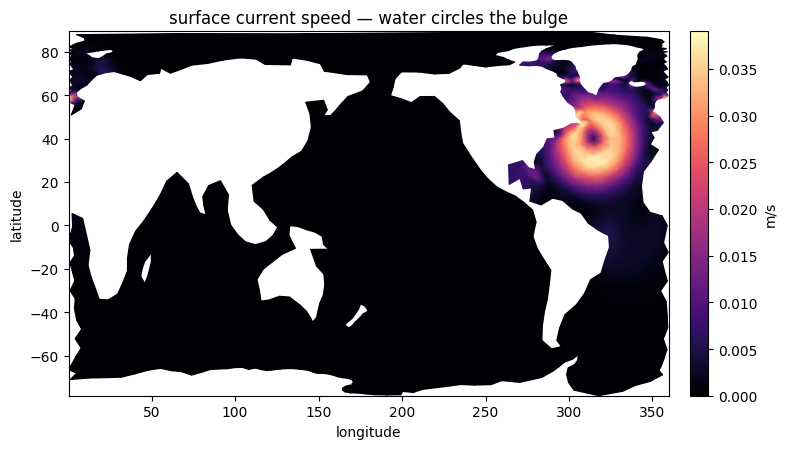

surface bulge : 0.298 m
peak current  : 0.039 m/s


In [6]:
speed = np.linalg.norm(np.asarray(state.uvnode[:, 0, :]), axis=-1)

plot_field(state.eta_n, "sea-surface height after 8 h — the blob bulges the surface",
           cmap="RdBu_r", units="m")
plot_field(speed, "surface current speed — water circles the bulge",
           cmap="magma", units="m/s")

print(f"surface bulge : {float(jnp.max(jnp.abs(state.eta_n))):.3f} m")
print(f"peak current  : {speed.max():.3f} m/s")

### Is the model healthy?

`state_diagnostics` reduces the whole state to a handful of numbers. It is the first thing to look at
when a run misbehaves: any `NaN`, or a velocity climbing towards infinity, shows up here.

In [7]:
from fesom_jax.diagnostics import state_diagnostics, format_diagnostics

diags = state_diagnostics(state, fields=["T", "S", "uv", "eta_n", "w"])
print(format_diagnostics(diags, label="pi after 300 steps"))

[diagnostics pi after 300 steps] FINITE  n_nonfinite=0
  max|uv|=0.05669  max|uvnode|=0.03619  max|w|=0.0001786  max|eta|=0.2976
  T[0,14.99]  S[0,35]  a_ice_max=0  m_ice_max=0


---
# The differentiable part

Everything so far, any ocean model can do. Here is what this one adds.

`jax.grad` differentiates *through the entire model* — through all 300 timesteps, through the
iterative sea-surface-height solver, through the advection scheme. Ask it a question of the form
"if I nudge this input, how does that output move?" and it answers **exactly** (not by re-running
with a slightly different value, but by propagating derivatives backwards).

### 1. Sensitivity to the physics knobs

Ocean models contain tuning parameters that stand in for processes too small to simulate — how
strongly turbulence mixes heat downward, how vigorously eddies stir. Historically these are tuned by
hand. Here we can just *ask* how much each one matters.

In [8]:
from fesom_jax.params import Params

# one number describing the run: the average surface temperature after 50 steps
def mean_surface_T(params):
    s = integrate(state0, mesh, op, stress, n_steps=50, params=params, dt=DT)
    return jnp.mean(s.T[:, 0])

t0 = time.time()
g = jax.grad(mean_surface_T)(Params.defaults())     # one backward pass = ALL sensitivities
print(f"gradient in {time.time() - t0:.1f} s\n")

labels = {"k_ver": "vertical mixing of heat",
          "a_ver": "vertical mixing of momentum",
          "k_gm":  "eddy stirring (GM)  [OFF in this run]",
          "redi_kmax": "eddy mixing along density surfaces (Redi)  [OFF in this run]"}

print("d(mean surface T) / d(parameter):")
for name, what in labels.items():
    print(f"  {name:<10} {float(getattr(g, name)):+.3e}   {what}")

gradient in 37.1 s

d(mean surface T) / d(parameter):
  k_ver      -6.859e-03   vertical mixing of heat
  a_ver      -1.962e-06   vertical mixing of momentum
  k_gm       +0.000e+00   eddy stirring (GM)  [OFF in this run]
  redi_kmax  +0.000e+00   eddy mixing along density surfaces (Redi)  [OFF in this run]


Read the first line as: *"raising the vertical mixing coefficient `k_ver` by 1 changes the mean
surface temperature by −6.9e-03 °C."* One backward pass gives the sensitivity to **every** parameter
at once — that is the property that makes gradient-based calibration, and neural-network training,
possible.

Notice that the two eddy parameters come back as **exactly zero**. That is not a bug and not a
rounding artefact: the eddy scheme is switched off in this simple run, so those knobs genuinely have
no influence on the answer, and the gradient says so exactly. A finite-difference estimate would have
returned a small non-zero number here — numerical noise you would then have to second-guess. The
adjoint does not guess.

### 2. An adjoint sensitivity map

Now the same trick, but backwards in a more interesting direction. Ask:

> *"The average temperature of the tropics at the end of the run — which water, at the **start**,
> did it come from?"*

The answer is a value at every one of the 3,140 points: how much that starting point influenced the
final tropical average. This is an **adjoint sensitivity map**, and it is the tool oceanographers use
to trace where water (and heat, and carbon) came from.

adjoint map in 25.9 s; shape (3140, 48) (nodes x levels)


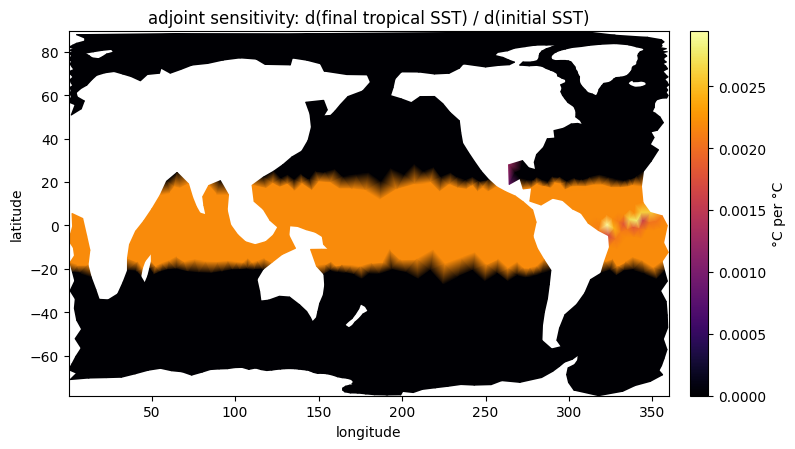

In [9]:
import dataclasses

tropics = jnp.asarray((np.abs(lat) < 20).astype(float))     # the region we ask about

def tropical_T(T_initial):
    s = dataclasses.replace(state0, T=T_initial)            # start from a modified temperature field
    sN = integrate(s, mesh, op, stress, n_steps=50, dt=DT)
    return jnp.sum(sN.T[:, 0] * tropics) / jnp.sum(tropics)  # mean tropical surface T at the end

t0 = time.time()
sens = jax.grad(tropical_T)(state0.T)      # -> one number per (node, depth level)
print(f"adjoint map in {time.time() - t0:.1f} s; shape {sens.shape} (nodes x levels)")

plot_field(sens[:, 0], "adjoint sensitivity: d(final tropical SST) / d(initial SST)",
           cmap="inferno", units="°C per °C")

The map lights up exactly where you would hope: **the tropics themselves**, because over 50 steps
(~1.4 hours) heat has barely moved. Run it for longer and the pattern spreads upstream along the
currents that feed the region — the model tells you where the water came from.

> **An honest caveat.** The ocean is chaotic, so these gradients are only trustworthy over short
> windows — hours to days, not decades. Push too far and the gradient explodes. This is a property
> of the *ocean*, not of the code, and it is the central limitation of the whole approach. It is
> documented in the README under
> [Limitations](../README.md#limitations--what-it-can-and-cant-do), and there are
> ways around it (ensemble-averaged adjoints, gradient-free methods).

---
## Where to go next

- **[`02_core2_realistic.ipynb`](02_core2_realistic.ipynb)** — the real thing: a 1° global ocean,
  driven by observed weather, with sea ice. This is the configuration used for science.
- **[`docs/USER_GUIDE.md`](../docs/USER_GUIDE.md)** — driving long runs from a single YAML file,
  restarts, and multi-GPU.
- **[`docs/DATA.md`](../docs/DATA.md)** — the input data the realistic setups need, and where to
  point the model at it.
- **[`README.md`](../README.md)** — what the model can and cannot do, and how fast it runs.